In [22]:
import pandas as pd
from pathlib import Path

# Cartella con i CSV
data_dir = Path("data")

# Lista dei CSV nella cartella
csv_files = sorted(data_dir.glob("*.csv"))

dfs = []

for csv_file in csv_files:
    print(f"Carico: {csv_file.name}")
    
    # Estrai la parte dopo l'ultimo '_' e senza '.csv'
    subtype = csv_file.stem.split("_")[-1]
    
    # Carica CSV saltando la prima riga
    df = pd.read_csv(csv_file, skiprows=1, header=0)[['junction_aa']]
    
    # Rimuove la C iniziale e la W finale (solo se presenti)
    df['junction_aa'] = df['junction_aa'].str.replace(r'^C|W$', '', regex=True)
    df = df.rename(columns={"junction_aa": "sequence"})

    
    # Aggiungi la nuova colonna
    df["isotype"] = subtype
    
    dfs.append(df)
    
# Concatena tutti i dataframe in uno solo
if dfs:  # controlla che la lista non sia vuota
    df_all = pd.concat(dfs, ignore_index=True)
    # Salva il risultato in un nuovo CSV
    df_all.to_csv("all_isotypes.csv", index=False)
    print("File unito salvato come 'all_isotypes.csv'")
else:
    print("Nessun CSV trovato nella cartella 'data'.")


Carico: ERR220445_Heavy_IGHG.csv
Carico: ERR3004232_1_Heavy_IGHM.csv
Carico: SRR13082955_1_Heavy_IGHE.csv
Carico: SRR8283601_1_Heavy_IGHA.csv
Carico: SRR8283601_1_Heavy_IGHD.csv
File unito salvato come 'all_isotypes.csv'


In [23]:
import os
from evaluate_mlm import *
# Nome della cartella da creare
cartella = "img"
# Creazione della cartella se non esiste
if not os.path.exists(cartella):
    os.makedirs(cartella)
    print(f"Cartella '{cartella}' creata con successo!")
else:
    print(f"La cartella '{cartella}' esiste già.")

model_path = 'Chrode/H3BERTa'
csv_file ='all_isotypes.csv'
embedding_file = "embeddings_file.pkl"

# Load the dataset
data = pd.read_csv(csv_file)

# Load the model and tokenizer
tokenizer, model = load_model_and_tokenizer(model_path)

# Compute or load embeddings
data = load_or_compute_embeddings(data, tokenizer, model, embedding_file)

La cartella 'img' esiste già.


Some weights of RobertaModel were not initialized from the model checkpoint at Chrode/H3BERTa and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Computing embeddings...


100%|██████████| 262/262 [00:01<00:00, 153.66it/s]

Embeddings saved to embeddings_file.pkl


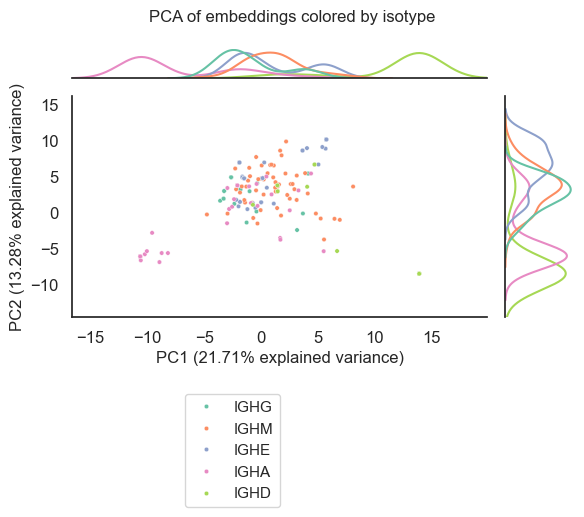

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------- Carica il file ----------
df = pd.read_pickle("embeddings_file.pkl")

# Estraggo gli embeddings dalla colonna "embeddings"
embeddings = np.vstack(df["embeddings"].values)

# ---------- PCA ----------
pca = PCA(n_components=2, svd_solver='randomized')
reduced_embeddings = pca.fit_transform(embeddings)
explained_variance = pca.explained_variance_ratio_ * 100  # in %

# Aggiungo le coordinate PCA al dataframe
df["pca1"] = reduced_embeddings[:, 0]
df["pca2"] = reduced_embeddings[:, 1]

# (opzionale) salva le coordinate PCA
# reduction_output_file = "embeddings_pca.csv"
# df.to_csv(reduction_output_file, sep=",", index=False)
# print(f"PCA coordinates saved to {reduction_output_file}")

# ---------- Plot stile jointplot ----------
hue_class = "isotype"
plot_title = "PCA of embeddings colored by isotype"

sns.set(style="white")

g = sns.jointplot(
    x="pca1",
    y="pca2",
    hue=hue_class,
    palette="Set2",
    data=df,
    s=10,
    marginal_kws={'common_norm': False, 'fill': False}
)

g.figure.suptitle(plot_title, fontsize=12)

# Limiti assi con un po' di margine
g.ax_joint.set_xlim(df['pca1'].min() - 6, df['pca1'].max() + 6)
g.ax_joint.set_ylim(df['pca2'].min() - 6, df['pca2'].max() + 6)

# Label degli assi con varianza spiegata
plt.xlabel(f'PC1 ({explained_variance[0]:.2f}% explained variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}% explained variance)', fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legenda (senza titolo, in posizione custom)
plt.legend(title=None, loc='best', bbox_to_anchor=(0.5, -0.35), borderaxespad=0.)

plt.tight_layout()
plt.show()


/tmp/ipykernel_680165/4091820266.py:54: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sub_df['umap2'], ax=ax_marg_y, color=style['color'],
/tmp/ipykernel_680165/4091820266.py:54: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sub_df['umap2'], ax=ax_marg_y, color=style['color'],
/tmp/ipykernel_680165/4091820266.py:54: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sub_df['umap2'], ax=ax_marg_y, color=style['color'],
/tmp/ipykernel_680165/4091820266.py:54: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sub_df['umap2'], ax=ax_ma

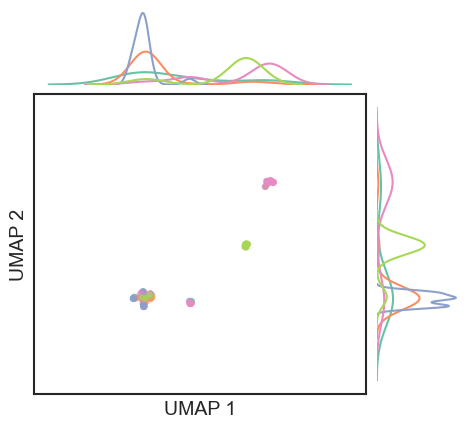

<Figure size 300x100 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.gridspec as gridspec

def plot_umap_single_gene_INSCAPE(df, gene_col, title,
                                  file_suffix="output_umap",
                                  custom_palette=None):
    
    # Palette fallback se non fornita
    if custom_palette is None:
        unique_vals = df[gene_col].dropna().unique()
        base_colors = sns.color_palette("Set2", len(unique_vals))
        custom_palette = {
            val: {"color": base_colors[i], "size": 12, "marker": "o"}
            for i, val in enumerate(unique_vals)
        }
    
    # Pulizia del valore gene: prendi parte prima di '-'
    df[gene_col] = df[gene_col].astype(str).str.split('-', n=1).str[0]

    # Layout con margini KDE
    fig = plt.figure(figsize=(5.5, 5))
    gs = gridspec.GridSpec(
        2, 2,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        wspace=0.05,
        hspace=0.05
    )

    ax_main = fig.add_subplot(gs[1, 0])
    ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_main)

    handles = []
    labels = []

    for gene_val in df[gene_col].dropna().unique():
        sub_df = df[df[gene_col] == gene_val]
        style = custom_palette.get(gene_val, {'color': 'grey', 'size': 10, 'marker': 'o'})
        
        # Main scatter
        sc = ax_main.scatter(sub_df['umap1'], sub_df['umap2'],
                             c=[style['color']] * len(sub_df),
                             s=style['size'], marker=style['marker'],
                             alpha=0.4, label=gene_val)
        handles.append(sc)
        labels.append(gene_val)

        # KDE marginali
        sns.kdeplot(sub_df['umap1'], ax=ax_marg_x, color=style['color'],
                    fill=False, linewidth=1.5, common_norm=False)
        sns.kdeplot(sub_df['umap2'], ax=ax_marg_y, color=style['color'],
                    fill=False, linewidth=1.5, common_norm=False, vertical=True)

    # Main plot settings
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.set_xlabel("UMAP 1", fontsize=14)
    ax_main.set_ylabel("UMAP 2", fontsize=14)

    ax_marg_x.axis('off')
    ax_marg_y.axis('off')

    # Spine thickness
    for ax in [ax_main, ax_marg_x, ax_marg_y]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    # Salva senza legenda
    plt.tight_layout()
    fig.savefig(f"{file_suffix}_umap_{gene_col}_NO_LEGEND.png",
                dpi=300, bbox_inches='tight')

    # --- Legenda separata ---
    fig_legend = plt.figure(figsize=(3, 1))
    fig_legend.legend(handles, labels, title=title,
                      loc='center', fontsize=10, title_fontsize=12,
                      frameon=False, markerscale=2,
                      ncol=2, columnspacing=0.4, handletextpad=0.4)
    
    fig_legend.savefig(f"{file_suffix}_umap_{gene_col}_LEGEND.svg",
                       dpi=300, bbox_inches='tight')

    plt.show()
    plt.close(fig)
    plt.close(fig_legend)

plot_umap_single_gene_INSCAPE(
    df=df,
    gene_col="isotype",
    title="UMAP by Isotype",
    file_suffix="Isotype_UMAP"
)
